findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.


Parsed 300 from ./scaling_1024_s1.log
Parsed 300 from ./scaling_1024_s2.log
Parsed 300 from ./scaling_1024_s3.log
Parsed 300 from ./scaling_1024_s4.log
Parsed 300 from ./scaling_1024_s5.log
Parsed 300 from ./scaling_2048_s1.log
Parsed 300 from ./scaling_2048_s2.log
Parsed 300 from ./scaling_2048_s3.log
Parsed 300 from ./scaling_2048_s4.log
Parsed 300 from ./scaling_2048_s5.log
Parsed 300 from ./scaling_4096_s1.log
Parsed 300 from ./scaling_4096_s2.log
Parsed 300 from ./scaling_4096_s3.log
Parsed 300 from ./scaling_4096_s4.log
Parsed 300 from ./scaling_4096_s5.log
Parsed 300 from ./scaling_8192_s1.log
Parsed 300 from ./scaling_8192_s2.log
Parsed 300 from ./scaling_8192_s3.log
Parsed 300 from ./scaling_8192_s4.log
Parsed 300 from ./scaling_8192_s5.log
Parsed 300 from ./scaling_16384_s1.log
Parsed 300 from ./scaling_16384_s2.log
Parsed 300 from ./scaling_16384_s3.log
Parsed 300 from ./scaling_16384_s4.log
Parsed 300 from ./scaling_16384_s5.log
Parsed 300 from ./scaling_32768_s1.log
Parsed

findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times Ne

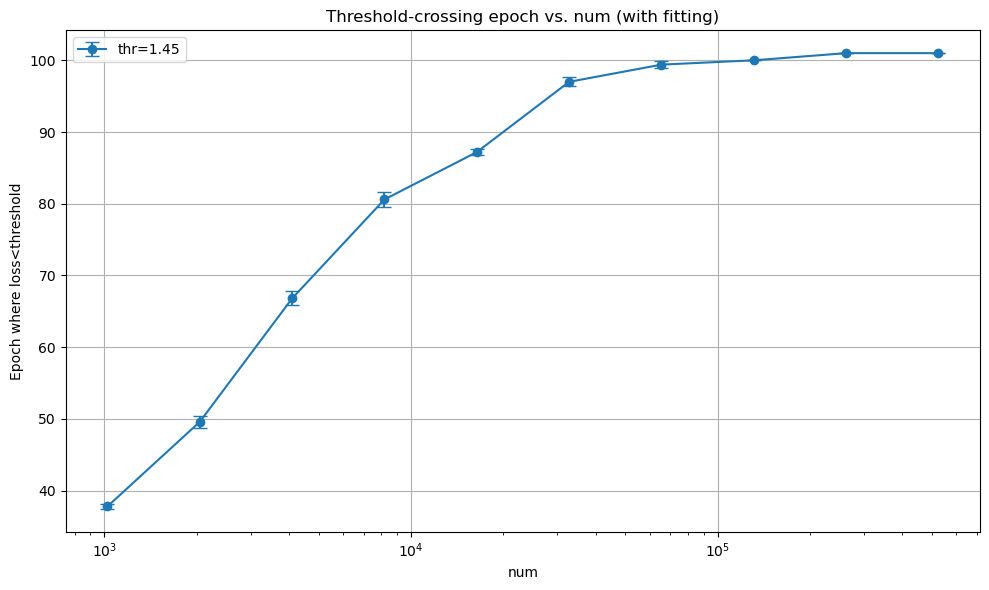

findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times Ne

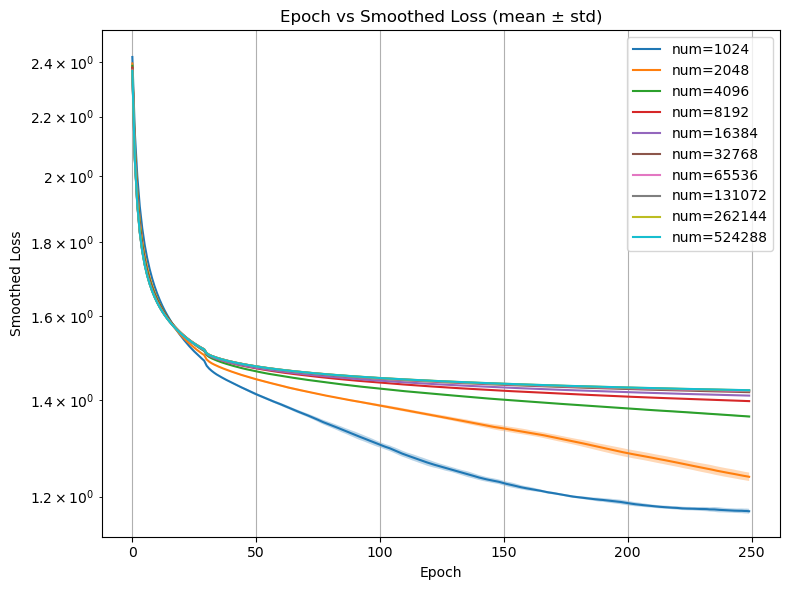

In [12]:
import os  
import re  
import math  
import matplotlib.pyplot as plt  
import numpy as np  
from scipy.optimize import curve_fit  

# ----------------------- 日志解析 -----------------------
def parse_log(log_file):  
    pattern = r'^(\d+)\s+([\d\.Ee\+\-]+)'  
    results = []  
    if not os.path.exists(log_file):  
        return results  
    with open(log_file, 'r') as f:  
        for line in f:  
            match = re.match(pattern, line.strip())  
            if match:  
                epoch = int(match.group(1))  
                total_loss = float(match.group(2))  
                results.append((epoch, total_loss))  
    return results  


# ----------------------- 高斯平滑 -----------------------
def smooth_losses(losses, window=10):
    smoothed = []  
    sigma = window / 2.0  
    two_sigma_sq = 2 * sigma * sigma  
    for i in range(len(losses)):  
        start = max(0, i - window + 1)  
        window_vals = losses[start:i+1]  
        weights = [math.exp(-((i - j) ** 2) / two_sigma_sq) for j in range(start, i+1)]
        weighted_sum = sum(v * w for v, w in zip(window_vals, weights))  
        smoothed.append(weighted_sum / sum(weights))  
    return smoothed  


# ----------------------- 找第一个 loss < threshold 的 epoch -----------------------
def find_first_below_threshold(losses, thr):
    for i, v in enumerate(losses):
        if v < thr:
            return i + 1  # epoch 从 1 计数
    return None


# ----------------------- 拟合函数 -----------------------
def complex_sublog_fit(x, y):
    """
    拟合 y = a * log(b * log(c*x + d) + e) + f
    """
    def model(x, a, b, c, d, e, f):
        return a * np.log(b * np.log(c * x + d) + e) + f

    x = np.array(x)
    y = np.array(y)

    initial_guess = [1.0, 1.0, 1e-5, 1.0, 1.0, 0.0]

    popt, _ = curve_fit(model, x, y, p0=initial_guess, maxfev=20000)

    def fit_fn(x_data):
        return model(np.array(x_data), *popt)

    return popt, fit_fn


# ----------------------- 主流程 -----------------------
def main():  
    nums = [1024, 2048, 4096, 8192, 16384, 
            32768, 65536, 131072, 262144, 524288]

    thresholds = [1.45]  
    
    convergence_data = {thr: [] for thr in thresholds}
    num_loss_curves = {}

    for num in nums:
        all_runs_smoothed_losses = []
        run_convergence_epochs = {thr: [] for thr in thresholds}

        for turn in [1, 2, 3, 4, 5]:
            log_file = f"./scaling_{num}_s{turn}.log"
            ep_loss_pairs = parse_log(log_file)
            print(f"Parsed {len(ep_loss_pairs)} from {log_file}")

            if not ep_loss_pairs:
                continue

            ep_loss_pairs.sort(key=lambda x: x[0])
            epochs = [p[0] for p in ep_loss_pairs][:250]
            losses = [p[1] for p in ep_loss_pairs][:250]

            smoothed_losses = smooth_losses(losses, window=30)
            all_runs_smoothed_losses.append(smoothed_losses)

            # ----- 用新的判定逻辑 -----
            for thr in thresholds:
                ep = find_first_below_threshold(smoothed_losses, thr)
                if ep is None:
                    ep = float("inf")
                run_convergence_epochs[thr].append(ep)

        # 聚合
        if all_runs_smoothed_losses:
            arr = np.array(all_runs_smoothed_losses)
            mean_curve = np.mean(arr, axis=0)
            std_curve = np.std(arr, axis=0)
            num_loss_curves[num] = (epochs, mean_curve, std_curve)

            for thr in thresholds:
                avg_ep = np.mean(run_convergence_epochs[thr])
                std_ep = np.std(run_convergence_epochs[thr])
                convergence_data[thr].append((num, avg_ep, std_ep))

    # ------------------ 多 threshold 并排展示 ------------------
    plt.figure(figsize=(10, 6))

    for thr, pts in convergence_data.items():
        pts_sorted = sorted(pts, key=lambda x: x[0])
        x_vals = [x for (x, _, _) in pts_sorted]
        y_vals = [y for (_, y, _) in pts_sorted]
        y_errs = [std for (_, _, std) in pts_sorted]
        print(x_vals)
        print(y_vals)
        # 原始误差条
        plt.errorbar(x_vals, y_vals, yerr=y_errs, fmt='-o', capsize=5,
                     label=f"thr={thr}")

        # # ----- 拟合曲线 -----
        # finite_x = [x for x, y in zip(x_vals, y_vals) if np.isfinite(y)]
        # finite_y = [y for y in y_vals if np.isfinite(y)]

        # if len(finite_x) >= 3:
        #     popt, fit_fn = complex_sublog_fit(finite_x, finite_y)
        #     xs_fit = np.linspace(min(finite_x), max(finite_x), 200)
        #     ys_fit = fit_fn(xs_fit)
        #     plt.plot(xs_fit, ys_fit, '--', label=f"fit thr={thr}")

    plt.xlabel("num")
    plt.ylabel("Epoch where loss<threshold")
    plt.xscale("log")
    plt.title("Threshold-crossing epoch vs. num (with fitting)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


    # ------------------ 平滑 Loss 曲线展示 ------------------
    plt.figure(figsize=(8, 6))
    for num, (eps, mean_curve, std_curve) in num_loss_curves.items():
        plt.plot(eps, mean_curve, label=f"num={num}")
        plt.fill_between(eps, mean_curve - std_curve,
                         mean_curve + std_curve, alpha=0.3)

    plt.xlabel("Epoch")
    plt.ylabel("Smoothed Loss")
    plt.yscale("log")
    plt.title("Epoch vs Smoothed Loss (mean ± std)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    main()


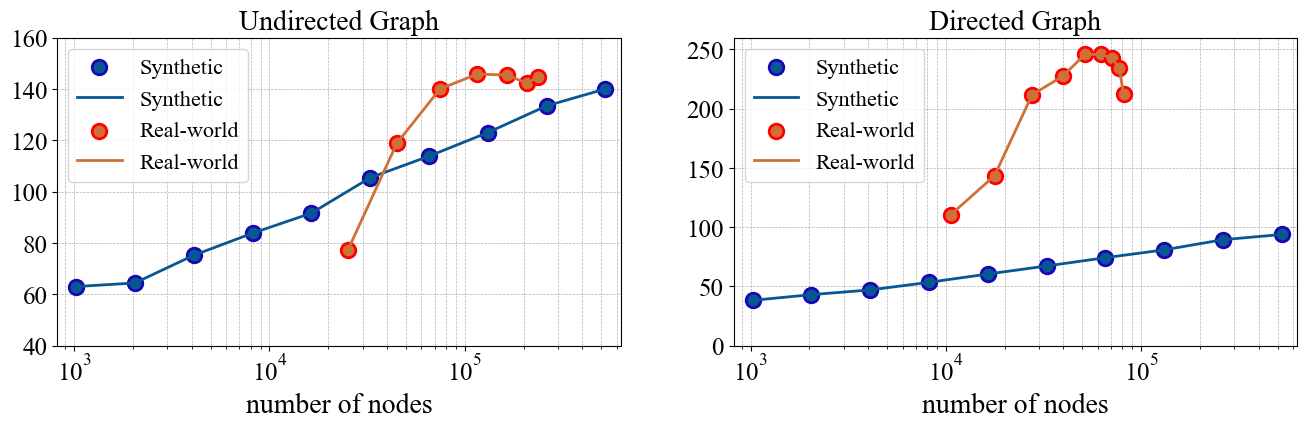

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ================== 手动输入区域 ==================

# ---- undirected synthetic ----
undir_syn_num = [2 ** 10, 2 ** 11, 2 ** 12, 2 ** 13, 2 ** 14, 2 ** 15, 2 ** 16, 2 ** 17, 2 ** 18, 2 ** 19]
undir_syn_values = [63, 64.4, 75.2, 83.8, 91.6, 105.4, 113.8, 123, 133.4, 140]

# ---- undirected real-world ----
undir_real_num = [25204, 44837, 74651, 115808, 163612, 208606, 235868]
undir_real_values = [77.2, 118.8, 140.0, 145.8, 145.4, 142.2, 144.75]

# ---- directed synthetic ----
dir_syn_num = [2 ** 10, 2 ** 11, 2 ** 12, 2 ** 13, 2 ** 14, 2 ** 15, 2 ** 16, 2 ** 17, 2 ** 18, 2 ** 19]
dir_syn_values = [38.2, 43.0, 47.0, 53.4, 60.4, 67.2, 74.2, 80.8, 89.4, 93.8]

# ---- directed real-world ----
dir_real_num = [10614, 17746, 27660, 39618, 51541, 62296, 70978, 77133, 81244]
dir_real_values = [110.6, 143.4, 211.8, 227.4, 245.8, 245.8, 242.4, 234.6, 212.0]


# ================== 拟合函数接口 ==================

def fit_undir_syn(x):
    log_x = np.log(x)
    coeff = np.polyfit(log_x, undir_syn_values, 1)
    poly = np.poly1d(coeff)
    return poly(log_x)

def fit_undir_real(x):
    return 20.97 * np.log(22.07 * np.log((7.02 * (10 ** -4)) * x + -5.54) - 53.10) + 62.04

def fit_dir_syn(x):
    return np.zeros_like(x)  # placeholder

def fit_dir_real(x):
    return np.zeros_like(x)  # placeholder


# ================== 绘图参数保持你原规范 ==================

plt.rcParams["font.family"] = "Times New Roman"
synthetic_color = "#075793"
synthetic_edge = "#1807B5"
real_color = "#CE7037"
real_edge = "red"

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
# fig.subplots_adjust(wspace=0.5)

def plot_scaling(ax, x_syn, y_syn, fit_syn, x_real, y_real, fit_real, title, ylim):
    # synthetic
    if x_syn:
        x_arr = np.array(x_syn)
        # fit_x = np.linspace(min(x_arr), max(x_arr), 200)
        # fit_y = fit_syn(fit_x)
        # ax.plot(fit_x, fit_y, color=synthetic_color, linewidth=3, linestyle='--', zorder=2)
        ax.scatter(x_arr, y_syn, color=synthetic_color, edgecolors=synthetic_edge,
                   linewidth=2, s=110, zorder=3, label='Synthetic')
        ax.plot(x_arr, y_syn, color=synthetic_color,
                   linewidth=2, zorder=3, label='Synthetic')

    # real-world
    if x_real:
        x_arr = np.array(x_real)
        # fit_x = np.linspace(min(x_arr), max(x_arr), 200)
        # fit_y = fit_real(fit_x)
        # ax.plot(fit_x, fit_y, color=real_color, linewidth=3, linestyle='--', zorder=2)
        ax.scatter(x_arr, y_real, color=real_color, edgecolors=real_edge,
                   linewidth=2, s=110, zorder=3, label='Real-world')
        ax.plot(x_arr, y_real, color=real_color,
                   linewidth=2, zorder=3, label='Real-world')

    ax.set_xscale("log")
    ax.set_xlabel("number of nodes", fontsize=20)
    ax.grid(True, which='both', linestyle='--', linewidth=0.5)
    ax.tick_params(labelsize=18)
    ax.set_xlim(0.8 * min(x_syn + x_real), 1.2 * max(x_syn + x_real))
    ax.set_title(title, fontsize=20)
    ax.legend(fontsize=16)
    ax.set_ylim(ylim)


# ================== 绘图 ==================

plot_scaling(
    ax=axes[0],
    x_syn=undir_syn_num,
    y_syn=undir_syn_values,
    fit_syn=fit_undir_syn,
    x_real=undir_real_num,
    y_real=undir_real_values,
    fit_real=fit_undir_real,
    title="Undirected Graph",
    ylim=[40, 160]
)

plot_scaling(
    ax=axes[1],
    x_syn=dir_syn_num,
    y_syn=dir_syn_values,
    fit_syn=fit_dir_syn,
    x_real=dir_real_num,
    y_real=dir_real_values,
    fit_real=fit_dir_real,
    title="Directed Graph",
    ylim=[0, 260]
)


plt.savefig("scalability_dual.pdf", bbox_inches="tight")
plt.show()
